In [4]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from src.analysis_utils import (
    drop_missing,
    subset_variables,
    recode_vaccination_variables,
    chi2_cramers_v_weighted,
    normalized_crosstab,
    screen_categorical_associations,
    fit_weighted_logit,
    fit_weighted_ordinal_logit,
    extract_odds_ratios,
    plot_heatmap,
    plot_odds_ratios,
    plot_weighted_coverage_bar,
    plot_stacked_vaccination
)

In [5]:
# Path relative to script.py
csv_path = "../data/cleaned_data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Display first 5 rows
df.head()

,Mothers_id,Birth_Order,Cluster_id,Household_id,Respondents_line_number,v005,Childs_Age,Received_Hep_B_at_birth,Hep_B_1,Hep_B_2,...,hhid,Number_of_household_members,Number_of_children_under_5,Result_of_household_interview,Region,Type_of_place_of_residence,Translator_used,Vaccination_at_Birth,Vaccination_Flag,wt
0,205 12 2,2,205,12,2,552441,14,Vaccination date on card,No,No,...,205 12,4,2,Completed,Kampot,Urban,No,True,None Post Birth,0.552441
1,512 26 7,1,512,26,7,297079,8,Vaccination date on card,No,No,...,512 26,14,3,Completed,Preah Sihanouk,Rural,No,True,None Post Birth,0.297079
2,512 29 5,1,512,29,5,297079,4,No,No,No,...,512 29,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.297079
3,641 16 1,2,641,16,1,64896,21,Vaccination date on card,No,No,...,641 16,3,2,Completed,Kep,Urban,No,True,None Post Birth,0.064896
4,513 6 1,4,513,6,1,287780,32,No,No,No,...,513 6,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.287780


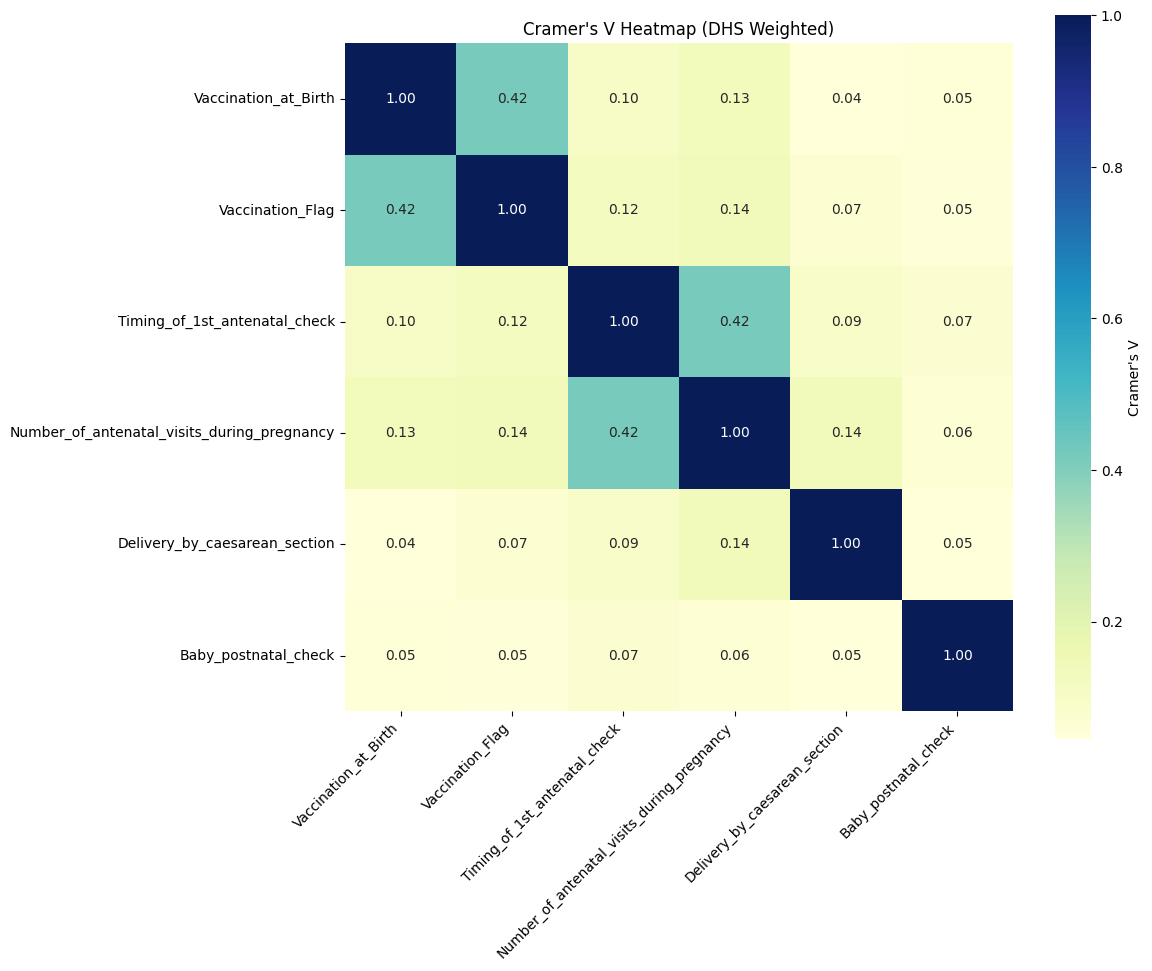

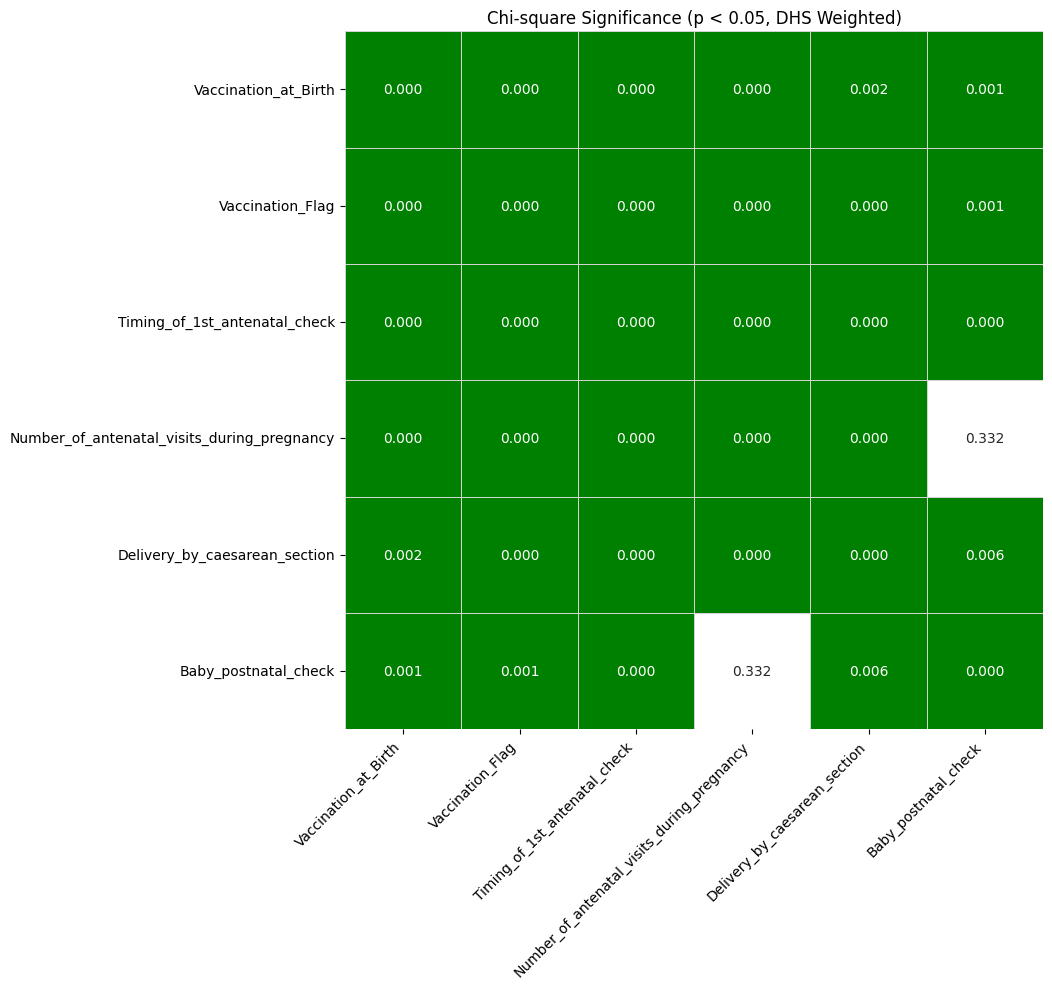

In [6]:
# ---------------------------------------------------
# 0. Select variables
# ---------------------------------------------------
mothers_vars = [
    "Vaccination_at_Birth",
    "Vaccination_Flag",
    "Timing_of_1st_antenatal_check",
    "Number_of_antenatal_visits_during_pregnancy",
    "Delivery_by_caesarean_section",
    "Baby_postnatal_check"
]

weight_col = "wt"
df_test = subset_variables(df, mothers_vars, weight_col=weight_col)
all_vars = [col for col in df_test.columns if col != weight_col]

# ---------------------------------------------------
# 1. Pairwise loop
# ---------------------------------------------------
cramers_results = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)
chi2_p_values   = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

for var1 in all_vars:
    for var2 in all_vars:
        if var1 == var2:
            cramers_results.loc[var1, var2] = 1.0
            chi2_p_values.loc[var1, var2]   = 0.0
        else:
            try:
                result = chi2_cramers_v_weighted(df_test, var1, var2, weight_col)
                cramers_results.loc[var1, var2] = result["cramers_v"]
                chi2_p_values.loc[var1, var2]   = result["p_value"]
            except Exception:
                cramers_results.loc[var1, var2] = np.nan
                chi2_p_values.loc[var1, var2]   = np.nan

# ---------------------------------------------------
# 2. Cramer's V Heatmap
# ---------------------------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    cramers_results.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Cramer's V"},
    square=True
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Cramer's V Heatmap (DHS Weighted)")
plt.tight_layout()
plt.savefig("../output/ATC_cramer.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------
# 3. Chi-square Significance Heatmap
# ---------------------------------------------------
alpha = 0.05
significant_mask = chi2_p_values.astype(float) < alpha
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(12, 10))
sns.heatmap(
    significant_mask,
    cmap=cmap,
    annot=chi2_p_values.round(3),
    fmt=".3f",
    square=True,
    linewidths=0.5,
    linecolor="lightgray",
    cbar=False
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Chi-square Significance (p < 0.05, DHS Weighted)")
plt.tight_layout()
plt.savefig("../output/ATC_chi.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# ---------------------------------------------------
# Binrary Logistic Rregression: Timing of 1st ANC
# ---------------------------------------------------

df = recode_vaccination_variables(df)

df_binary, fit_stats_binary = fit_weighted_logit(
    df=df,
    formula="Vaccination_at_Birth ~ Timing_of_1st_antenatal_check",
    weight_col="wt"
)

print("=== Binary Logit: Odds Ratios ===")
print(df_binary)
print("\n=== Binary Logit: Model Fit ===")
for k, v in fit_stats_binary.items():
    print(f"  {k}: {v}")

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Binary Logit: Odds Ratios ===
                                      OR   CI_lower   CI_upper    t_value  \
(Intercept)                    19.096207  15.397652  23.683165  26.854058   
Timing_of_1st_antenatal_check   0.890962   0.848172   0.935911  -4.597677   

                                     p_value  
(Intercept)                    3.874182e-148  
Timing_of_1st_antenatal_check   4.381755e-06  

=== Binary Logit: Model Fit ===
  n: 4814
  log_likelihood: -1173.3940925132806
  null_log_likelihood: -1185.7276970526434
  mcfadden_r2: 0.010401717502273367
  aic: 2349.3968687460433
  bic: 2363.7467522632473


In [8]:
# ---------------------------------------------------
# Ordinal Logistic Rregression: Timing of 1st ANC
# ---------------------------------------------------

df_ordinal, fit_stats_ordinal = fit_weighted_ordinal_logit(
    df=df,
    outcome="Vaccination_Flag_ord",
    predictors=["Timing_of_1st_antenatal_check"],
    weight_col="wt"
)

print("=== Ordinal Logit: Odds Ratios ===")
print(df_ordinal)
print("\n=== Ordinal Logit: Model Fit ===")
for k, v in fit_stats_ordinal.items():
    print(f"  {k}: {v}")

C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Ordinal Logit: Odds Ratios ===
                                     OR  CI_lower  CI_upper    t_value  \
Timing_of_1st_antenatal_check  0.863843  0.832961  0.895870  -7.880249   
0|1                            0.049749  0.042306  0.058501 -36.294486   
1|2                            0.081401  0.069448  0.095412 -30.956596   
2|3                            0.122268  0.105361  0.141888 -27.677319   

                                    p_value  
Timing_of_1st_antenatal_check  3.330669e-15  
0|1                            0.000000e+00  
1|2                            0.000000e+00  
2|3                            0.000000e+00  

=== Ordinal Logit: Model Fit ===
  n: 4814
  log_likelihood: -2823.8404941293334
  null_log_likelihood: -2864.8641735634797
  mcfadden_r2: 0.014319589672943778
  aic: 5655.680988258667
  bic: 5681.598122732039


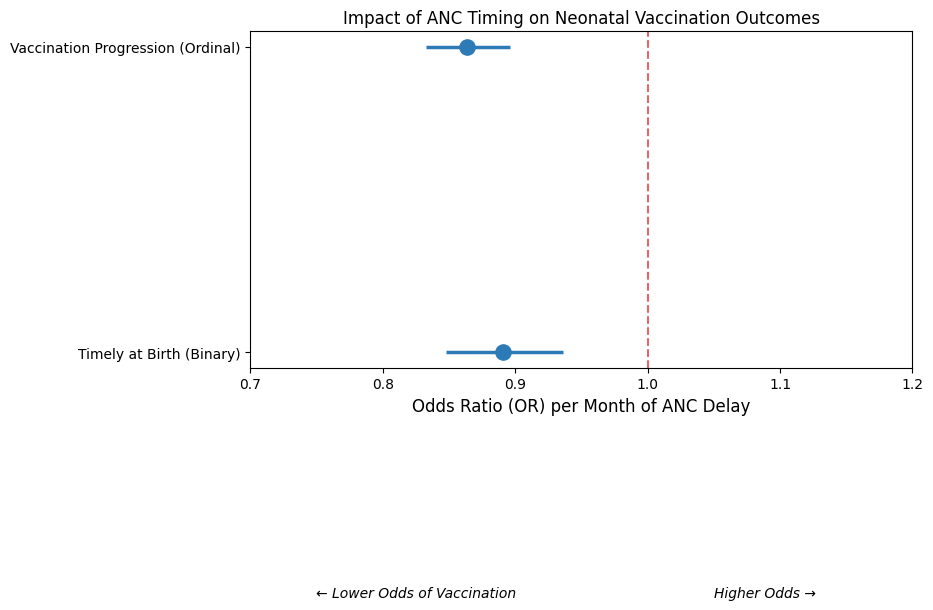

In [9]:
# ---------------------------------------------------
# Forest Plot: Timing of 1st ANC
# ---------------------------------------------------

binary_row = df_binary.loc[["Timing_of_1st_antenatal_check"]].copy()
binary_row.index = ["Timely at Birth (Binary)"]

ordinal_row = df_ordinal.loc[["Timing_of_1st_antenatal_check"]].copy()
ordinal_row.index = ["Vaccination Progression (Ordinal)"]

df_plot = pd.concat([binary_row, ordinal_row])

ax = plot_odds_ratios(df_plot, title="Impact of ANC Timing on Neonatal Vaccination Outcomes")
ax.figure.set_size_inches(10, 4)
ax.set_xlabel("Odds Ratio (OR) per Month of ANC Delay", fontsize=12)
ax.set_xlim(0.7, 1.2)
ax.text(0.75, -0.8, "← Lower Odds of Vaccination", fontsize=10, style="italic")
ax.text(1.05, -0.8, "Higher Odds →",               fontsize=10, style="italic")

plt.savefig("anc_timing_forest.png", dpi=300, bbox_inches="tight")
plt.savefig("../output/ANC_timing_forest_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# ---------------------------------------------------
# Ordinal Logistic Rregression: Number of ANC visits
# ---------------------------------------------------
df_ordinal_anc, fit_stats_ordinal_anc = fit_weighted_ordinal_logit(
    df=df,
    outcome="Vaccination_Flag_ord",
    predictors=["Number_of_antenatal_visits_during_pregnancy"],
    weight_col="wt"
)

print("=== Ordinal Logit: Odds Ratios ===")
print(df_ordinal_anc)

print("\n=== Ordinal Logit: Model Fit ===")
for k, v in fit_stats_ordinal_anc.items():
    print(f"  {k}: {v}")

C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Ordinal Logit: Odds Ratios ===
                                                   OR  CI_lower  CI_upper  \
Number_of_antenatal_visits_during_pregnancy  1.226480  1.183863  1.270632   
0|1                                          0.211919  0.172831  0.259848   
1|2                                          0.348970  0.286254  0.425426   
2|3                                          0.527988  0.434775  0.641185   

                                               t_value       p_value  
Number_of_antenatal_visits_during_pregnancy  11.314073  0.000000e+00  
0|1                                         -14.914992  0.000000e+00  
1|2                                         -10.415811  0.000000e+00  
2|3                                          -6.444533  1.159566e-10  

=== Ordinal Logit: Model Fit ===
  n: 4814
  log_likelihood: -2774.2295669531773
  null_log_likelihood: -2864.8641735634797
  mcfadden_r2: 0.031636615601767226
  aic: 5556.4591339063545
  bic: 5582.376268379727


In [12]:
# ---------------------------------------------------
# Binary Logistic Rregression: Number of ANC visits
# ---------------------------------------------------
df_binary_anc, fit_stats_binary_anc = fit_weighted_logit(
    df=df,
    formula="Vaccination_at_Birth ~ Number_of_antenatal_visits_during_pregnancy",
    weight_col="wt")

print("=== Binary Logit: Odds Ratios ===")
print(df_binary_anc)

print("\n=== Binary Logit: Model Fit ===")
for k, v in fit_stats_binary_anc.items():
    print(f"  {k}: {v}")

C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Binary Logit: Odds Ratios ===
                                                   OR  CI_lower  CI_upper  \
(Intercept)                                  6.465364  4.934856  8.470549   
Number_of_antenatal_visits_during_pregnancy  1.157365  1.096823  1.221249   

                                               t_value       p_value  
(Intercept)                                  13.542294  4.928243e-41  
Number_of_antenatal_visits_during_pregnancy   5.331375  1.019289e-07  

=== Binary Logit: Model Fit ===
  n: 4814
  log_likelihood: -1162.8996907275803
  null_log_likelihood: -1185.7276970526434
  mcfadden_r2: 0.019252317696387244
  aic: 2329.0382376979014
  bic: 2342.7579486918467


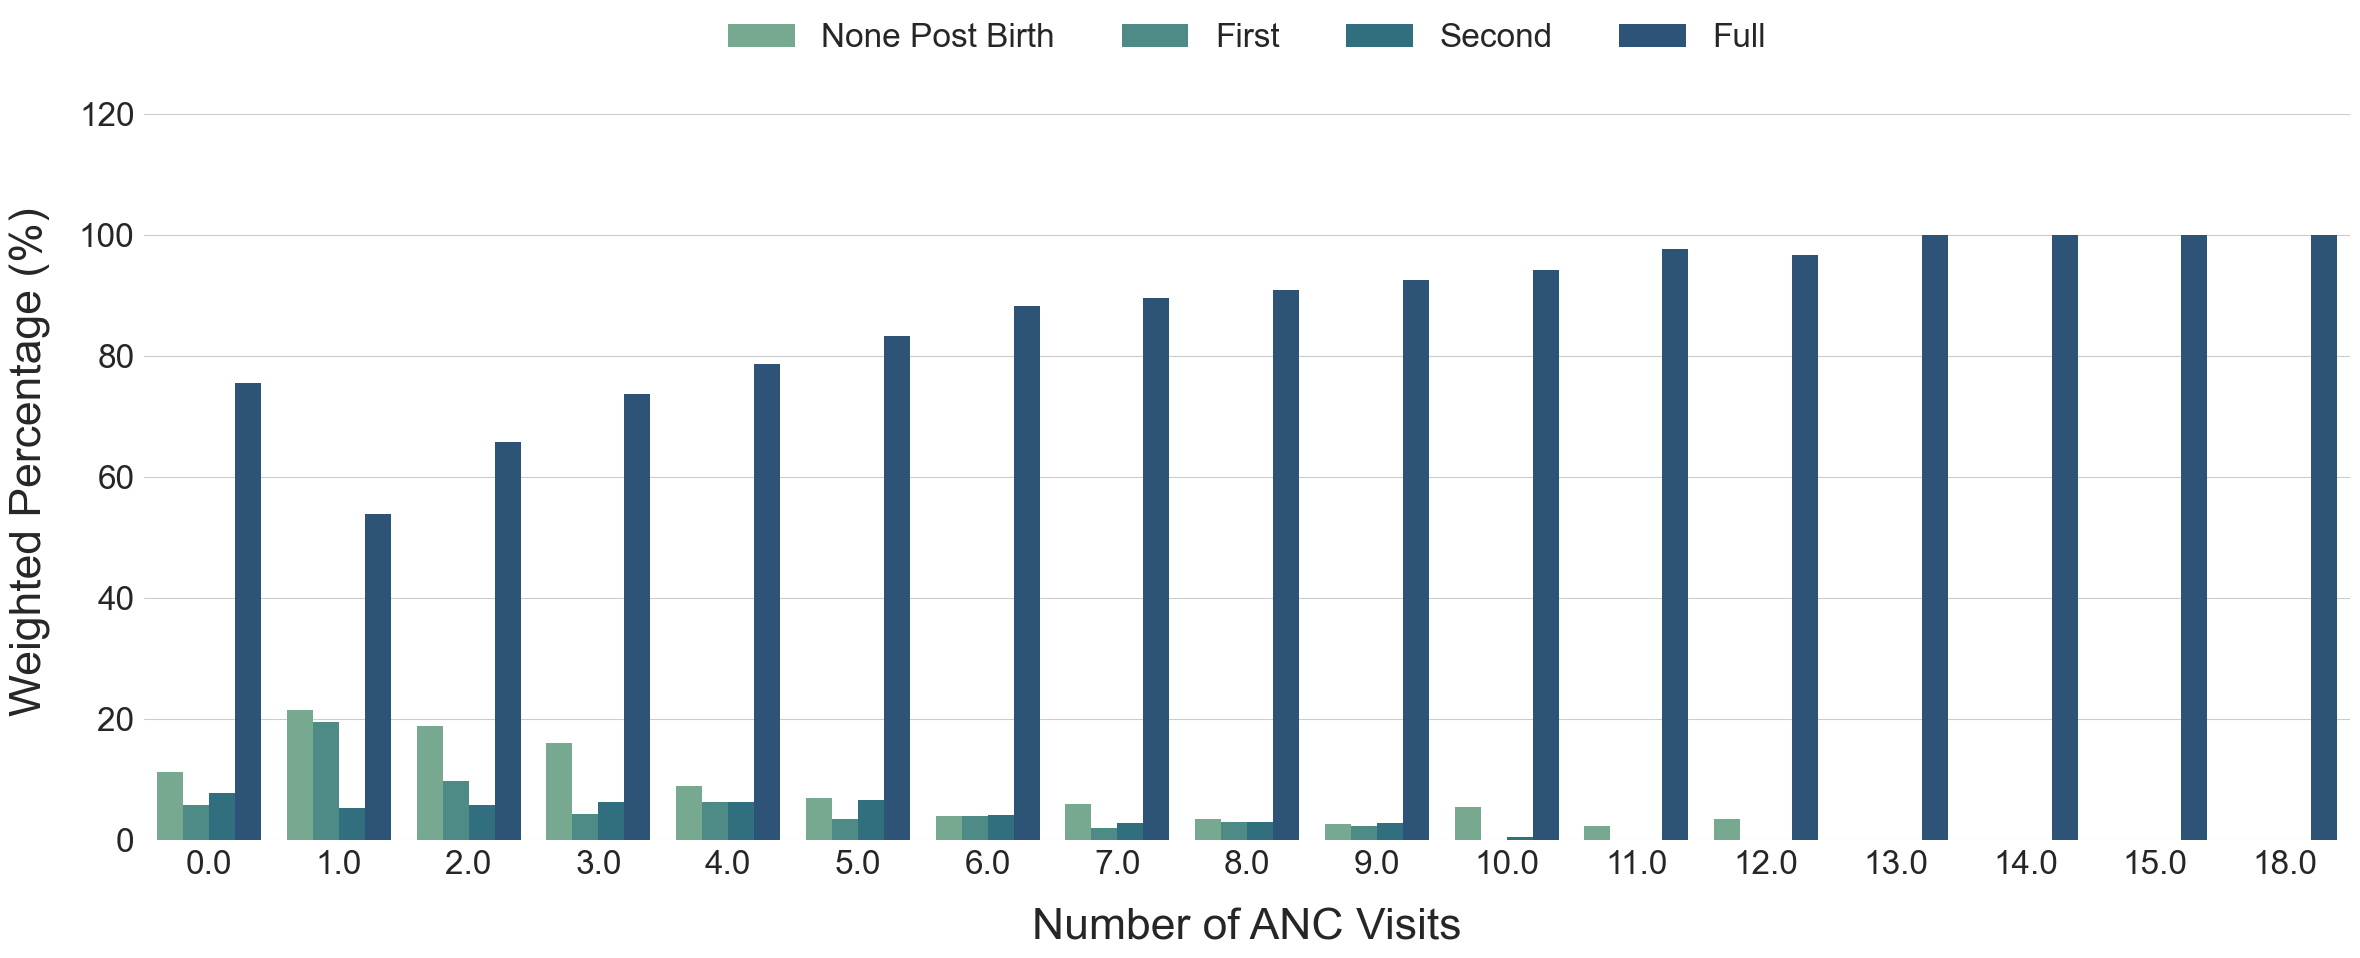

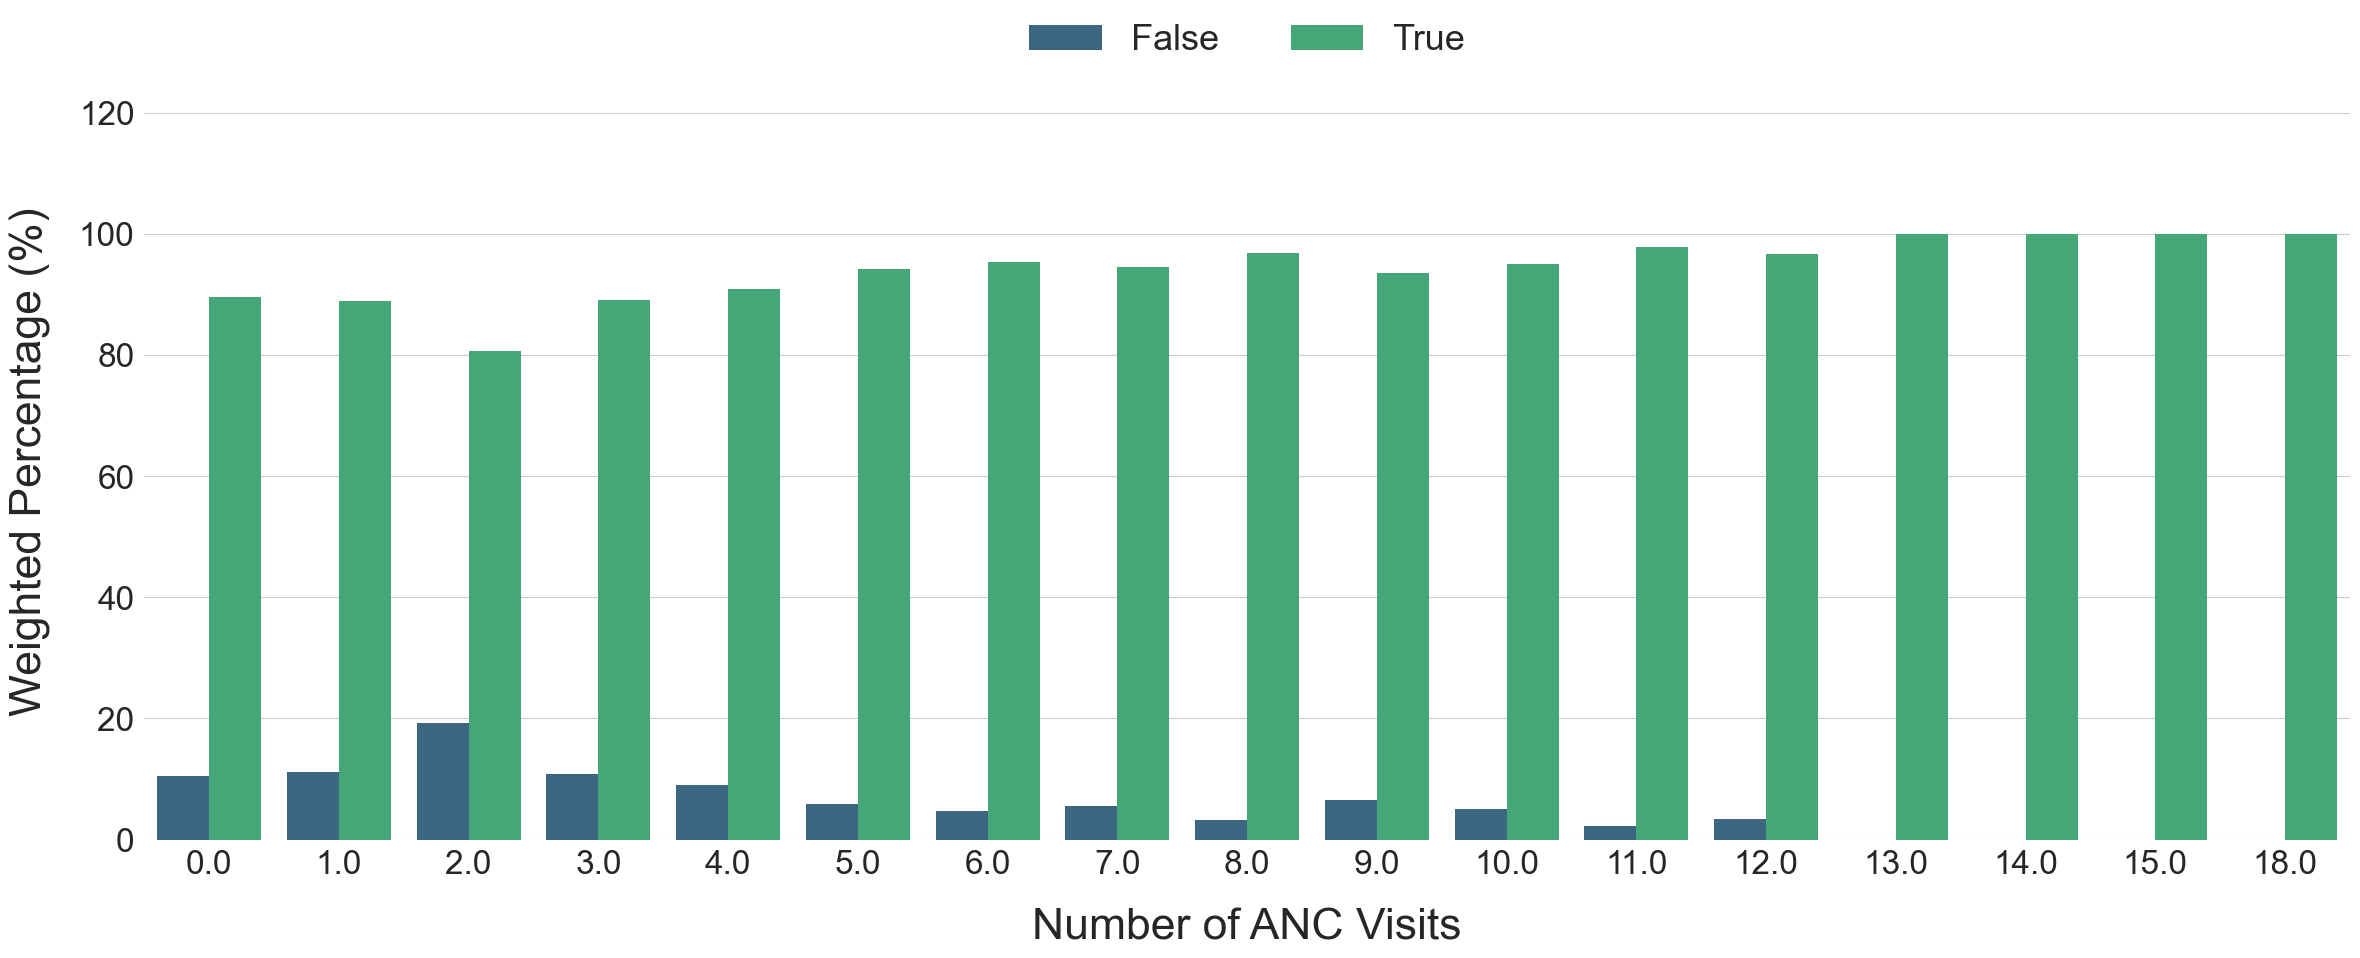

In [13]:
# ---------------------------------------------------
# 1. Define Function for Weighted Percentages
# ---------------------------------------------------
def get_weighted_pct(df, group_col, category_col, weight_col):
    """
    Compute weighted percentage of each category_col level
    within each group_col level.
    """
    grouped = (
        df.groupby([group_col, category_col])[weight_col]
        .sum()
        .reset_index()
    )
    grouped.columns = [group_col, category_col, "weighted_count"]
    totals = grouped.groupby(group_col)["weighted_count"].transform("sum")
    grouped["Percentage"] = (grouped["weighted_count"] / totals) * 100
    return grouped

# ---------------------------------------------------
# 2.Prepare Data
# ---------------------------------------------------
plot_df1 = get_weighted_pct(df, "Number_of_antenatal_visits_during_pregnancy", "Vaccination_Flag", "wt")
plot_df2 = get_weighted_pct(df, "Number_of_antenatal_visits_during_pregnancy", "Vaccination_at_Birth", "wt")

# ---------------------------------------------------
# 3. Figure 1: Post Birth Coverage by Number of ANC visits
# ---------------------------------------------------
plt.rcParams.update({"font.size": 20, "font.family": "sans-serif"})
sns.set_style("whitegrid")

plt.figure(figsize=(24, 10))
ax1 = sns.barplot(
    data=plot_df1,
    x="Number_of_antenatal_visits_during_pregnancy",
    y="Percentage",
    hue="Vaccination_Flag",
    hue_order=["None Post Birth", "First", "Second", "Full"],
    palette="crest",
    edgecolor="none"
)
ax1.set_ylabel("Weighted Percentage (%)", fontsize=32, labelpad=20)
ax1.set_xlabel("Number of ANC Visits", fontsize=32, labelpad=20)
ax1.set_ylim(0, 125)
ax1.tick_params(axis="x", labelsize=24)
ax1.tick_params(axis="y", labelsize=24)
ax1.legend(title="", fontsize=24, loc="upper center",
           bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("../output/Post_birth_coverage_by_num_ANC.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------
# 3. Figure 1: At-Birth Coverage by Number of ANC visits
# ---------------------------------------------------
plt.figure(figsize=(24, 10))
ax2 = sns.barplot(
    data=plot_df2,
    x="Number_of_antenatal_visits_during_pregnancy",
    y="Percentage",
    hue="Vaccination_at_Birth",
    palette="viridis",
    edgecolor="none"
)
ax2.set_ylabel("Weighted Percentage (%)", fontsize=32, labelpad=20)
ax2.set_xlabel("Number of ANC Visits", fontsize=32, labelpad=20)
ax2.set_ylim(0, 125)
ax2.tick_params(axis="x", labelsize=24)
ax2.tick_params(axis="y", labelsize=24)
ax2.legend(title="", fontsize=26, loc="upper center",
           bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("../output/At_birth_coverage_by_num_ANC.png", dpi=300, bbox_inches="tight")
plt.show()

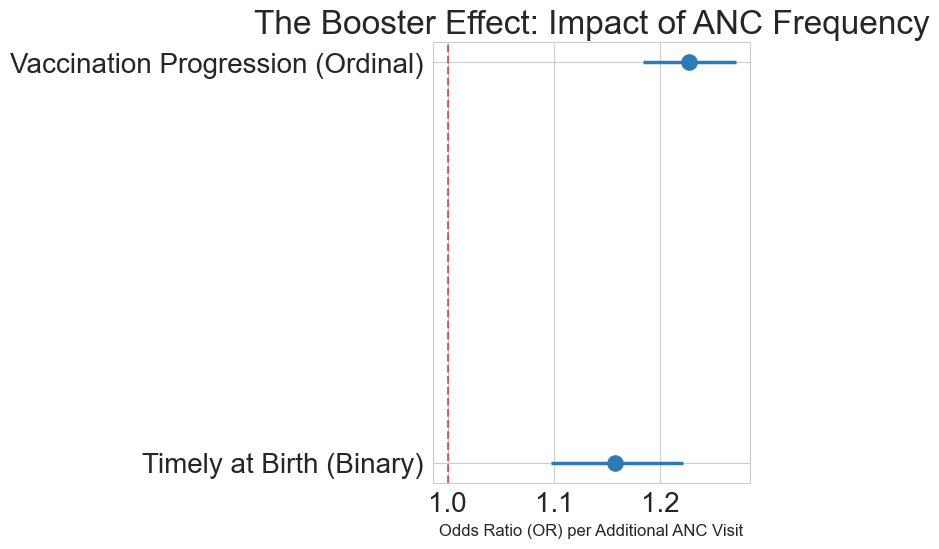

In [14]:
# ---------------------------------------------------
# Forest Plot: Number of ANC Visits
# ---------------------------------------------------
binary_row = df_binary_anc.loc[["Number_of_antenatal_visits_during_pregnancy"]].copy()
binary_row.index = ["Timely at Birth (Binary)"]

ordinal_row = df_ordinal_anc.loc[["Number_of_antenatal_visits_during_pregnancy"]].copy()
ordinal_row.index = ["Vaccination Progression (Ordinal)"]

df_plot_anc = pd.concat([binary_row, ordinal_row])[["OR", "CI_lower", "CI_upper", "p_value"]]


ax = plot_odds_ratios(df_plot_anc, title="The Booster Effect: Impact of ANC Frequency")
ax.set_xlabel("Odds Ratio (OR) per Additional ANC Visit", fontsize=12)

plt.savefig("../output/ANC_freq_forest_plot.png", dpi=300, bbox_inches="tight")
plt.show()